<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/movie_recommendation_system/movie_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load libraries

In [1]:
import pandas as pd
import numpy as np
import cv2
import ast
import requests
from tensorflow.keras.models import load_model
from google.colab import files
import matplotlib.pyplot as plt


Load the model

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load trained model
model = load_model("/content/drive/MyDrive/AI-python/lecture39/emotion_model.keras")

print(" Model loaded")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Model loaded


Load and clean movie dataset

In [3]:
# Load dataset
movies_df = pd.read_csv("/content/drive/MyDrive/AI-python/lecture41/tmdb10kmovies.csv")

# Clean genres column
movies_df["genres"] = movies_df["genres"].apply(ast.literal_eval)
movies_df["genres"] = movies_df["genres"].apply(
    lambda x: [g.lower() for g in x]
)

print(" Movie Dataset loaded")

 Movie Dataset loaded


Emotions label

In [4]:
emotion_labels = [
    "anger", "contempt", "disgust", "fear",
    "happiness", "neutral", "sadness", "surprise"
]

Emotions to genre mapping

In [5]:
emotion_to_genres = {
    "anger": ["action", "thriller", "crime", "war"],
    "contempt": ["crime", "drama", "thriller"],
    "disgust": ["horror", "thriller", "crime"],
    "fear": ["horror", "thriller", "mystery"],
    "happiness": ["comedy", "family", "fantasy", "animation", "music"],
    "neutral": ["drama", "documentary", "history", "tv movie"],
    "sadness": ["drama", "romance", "history", "war"],
    "surprise": ["science fiction", "adventure", "fantasy", "mystery", "western"]
}

Image input

In [6]:
def get_image_input():
    print("Choose input method:")
    print("1 - Upload from local (Colab)")
    print("2 - Load from Google Drive path")
    print("3 - Load from Image URL")

    choice = input("Enter choice (1/2/3): ")

    if choice == "1":
        uploaded = files.upload()
        image_path = list(uploaded.keys())[0]
        return image_path

    elif choice == "2":
        path = input("Enter full image path (Drive): ")
        return path

    elif choice == "3":
        url = input("Enter image URL: ")
        img_data = requests.get(url).content

        with open("temp.jpg", "wb") as f:
            f.write(img_data)

        return "temp.jpg"

    else:
        print("Invalid choice")
        return None

Display image

In [12]:
def display_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

Emotion Prediction

In [17]:
def predict_emotion(image_path, model):
    img = cv2.imread(image_path)

    # Resize to correct size according to the trainned model
    img = cv2.resize(img, (224, 224))

    img = img / 255.0
    img = img.reshape(1, 224, 224, 3)

    prediction = model.predict(img)
    emotion = emotion_labels[prediction.argmax()]

    return emotion



Recommendation function

In [18]:
def recommend_movies(emotion, movies_df, mapping, top_n=10):
    target_genres = mapping.get(emotion, [])

    df = movies_df.copy()

    def score(genres):
        return sum(1 for g in genres if g in target_genres)

    df["score"] = df["genres"].apply(score)

    df = df[df["score"] > 0]

    df = df.sort_values(
        by=["score", "vote_average", "popularity"],
        ascending=False
    )

    return df[["title", "genres", "vote_average"]].head(top_n)

Final pipeline

In [19]:
def run_movie_recommender():
    # Step 1: Get image
    image_path = get_image_input()

    if image_path is None:
        return

    # Step 2: Show image
    display_image(image_path)

    # Step 3: Predict emotion
    emotion = predict_emotion(image_path, model)
    print(f"\n Detected Emotion: {emotion}")

    # Step 4: Recommend movies
    recs = recommend_movies(emotion, movies_df, emotion_to_genres)

    print("\n Recommended Movies:\n")
    for i, row in recs.iterrows():
        print(f" {row['title']}  {row['vote_average']}")

Run

Choose input method:
1 - Upload from local (Colab)
2 - Load from Google Drive path
3 - Load from Image URL
Enter choice (1/2/3): 2
Enter full image path (Drive): /content/drive/MyDrive/AI-python/lecture40/fer2013_image_folder/happiness/20.png


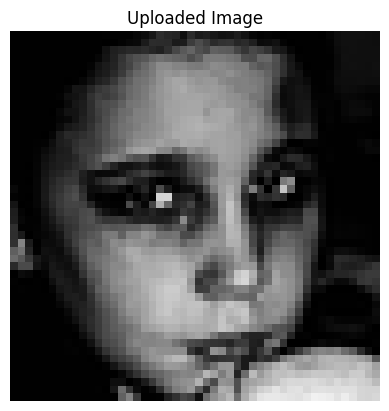

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

 Detected Emotion: neutral

 Recommended Movies:

 Prayers for Bobby  8.062
 Apollo 11  7.8
 The Count of Monte-Cristo  6.699
 The Lover in the Attic: A True Story  6.4
 Young Sister-In-Law 2  5.7
 Schindler's List  8.572
 Harakiri  8.378
 Ennio  8.337
 Paths of Glory  8.279
 Green Book  8.242


In [20]:
run_movie_recommender()